In [ ]:
!apt-get update
from google.colab import drive

# Use the 'force_remount' parameter to refresh credentials
drive.mount('/drive/', force_remount=True)

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Ign:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy Release
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Mounted at 

In [ ]:
!pip install stanza

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Downloading default packages for language: tr (Turkish) ...


INFO:stanza:Downloaded file to /root/stanza_resources/tr/default.zip
INFO:stanza:Finished downloading models and saved to /root/stanza_resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Loading these models for language: tr (Turkish):
| Processor | Package       |
-----------------------------
| tokenize  | imst          |
| mwt       | imst          |
| pos       | imst_charlm   |
| lemma     | imst_nocharlm |
| depparse  | imst_charlm   |
| ner       | starlang      |

INFO:stanza:Using device: cuda
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: depparse
INFO:stanza:Loading: ner
INFO:stanza:Done loading processors!


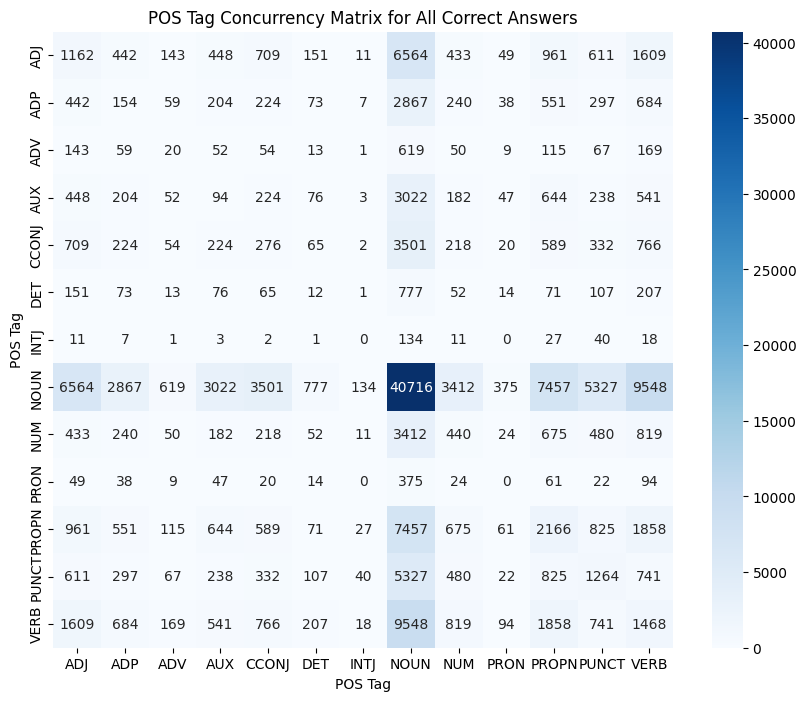

In [ ]:
import stanza
import numpy as np
import json
import nltk
from nltk.tokenize import word_tokenize
from string import punctuation
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive


nltk.download('punkt')

file_path = '/drive/MyDrive/Colab Notebooks/gpt4_generation_final.json'

with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)


stanza.download('tr')
nlp = stanza.Pipeline('tr')


def filter_tokens(tokens):
    return [token for token in tokens if token not in punctuation and len(token) > 1]


def create_concurrency_matrix(texts):

    tags = set()
    for text in texts:

        tokens = word_tokenize(text.lower())
        tokens = filter_tokens(tokens)
        doc = nlp(" ".join(tokens))
        for sentence in doc.sentences:
            for word in sentence.words:
                tags.add(word.upos)

    tags = sorted(list(tags))
    tag_index = {tag: idx for idx, tag in enumerate(tags)}
    matrix = np.zeros((len(tags), len(tags)))


    for text in texts:
        tokens = word_tokenize(text.lower())
        tokens = filter_tokens(tokens)
        doc = nlp(" ".join(tokens))
        for sentence in doc.sentences:
            sentence_tags = [word.upos for word in sentence.words]
            for i, tag1 in enumerate(sentence_tags):
                for j, tag2 in enumerate(sentence_tags):
                    if i != j:
                        idx1 = tag_index[tag1]
                        idx2 = tag_index[tag2]
                        matrix[idx1, idx2] += 1

    return matrix, tags


all_correct_texts = []
for value in data.values():
    all_correct_texts.extend(value.get("correct", []))


concurrency_matrix, tags = create_concurrency_matrix(all_correct_texts)


plt.figure(figsize=(10, 8))
sns.heatmap(concurrency_matrix, annot=True, xticklabels=tags, yticklabels=tags, cmap="Blues", fmt="g")
plt.title("POS Tag Concurrency Matrix for All Correct Answers")
plt.xlabel("POS Tag")
plt.ylabel("POS Tag")
plt.show()